# COMP-341 Assignment 02
## Hebbian, Neo-Hebbian, and Temporal Learning

**Student Name:** Zarmeena Jawad  
**Roll Number:** B23F0115AI125  
**Course:** Artificial Neural Network (COMP-341)  
**Instructor:** Dr. Abid Ali

This notebook implements all coding and theory tasks described in the assignment sheet for:
- Q1: Oja's Rule & Unsupervised PCA
- Q3: Differential Hebbian Learning & STDP

## 0. Environment Setup and Reproducibility

In [1]:
# If running on Colab and any package is missing, uncomment this line:
# !pip install -q numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.datasets import fetch_olivetti_faces, load_digits

# Reproducibility control.
GLOBAL_SEED = 117
rng = np.random.default_rng(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

## 1. Utility Functions

In [2]:
def normalize(v):
    """Return unit vector; if norm is zero, return copy unchanged."""
    n = np.linalg.norm(v)
    return v.copy() if n == 0 else v / n


def principal_angle_deg(a, b, ignore_sign=True):
    """Angle in degrees between vectors a and b."""
    ua = normalize(a)
    ub = normalize(b)
    c = np.clip(np.dot(ua, ub), -1.0, 1.0)
    if ignore_sign:
        c = abs(c)
    return np.degrees(np.arccos(c))


def remove_component(X, direction):
    """Deflation step: remove projection of X on a given direction."""
    return X - np.outer(X @ direction, direction)

## Q1: Oja's Rule and Unsupervised PCA [20 Marks]

### Task 2.1 — Basic Hebbian Rule (Unstable) [5 Marks]

In [3]:
# Create 2D correlated Gaussian data (200 points).
num_points = 200
mu = np.array([0.0, 0.0])
Sigma = np.array([
    [2.8, 2.2],
    [2.2, 2.1]
])

X_raw = rng.multivariate_normal(mu, Sigma, size=num_points)
X = X_raw - X_raw.mean(axis=0, keepdims=True)

print('X shape:', X.shape)
print('Estimated covariance:\n', np.cov(X.T))

X shape: (200, 2)
Estimated covariance:
 [[3.02070482 2.35842864]
 [2.35842864 2.19469249]]


In [4]:
def run_basic_hebbian(X, lr=0.018, epochs=70, shuffle=True):
    """
    Classical Hebbian update:
        w <- w + lr * y * x, y = w^T x

    Returns final weight and per-epoch diagnostics.
    """
    w = np.random.normal(0.0, 0.01, size=X.shape[1])

    norm_track = []
    w_track = []

    for _ in range(epochs):
        epoch_data = X[np.random.permutation(len(X))] if shuffle else X
        for sample in epoch_data:
            y = np.dot(w, sample)
            w += lr * y * sample

        norm_track.append(np.linalg.norm(w))
        w_track.append(w.copy())

    return w, np.array(norm_track), np.array(w_track)

In [5]:
# PCA reference direction.
pca_ref = PCA(n_components=2, random_state=GLOBAL_SEED)
pca_ref.fit(X)
pc1_ref = pca_ref.components_[0]

# Execute unstable Hebbian dynamics.
w_basic, norms_basic, hist_basic = run_basic_hebbian(X, lr=0.018, epochs=70)
angles_basic = np.array([principal_angle_deg(v, pc1_ref) for v in hist_basic])

print('Basic Hebbian final norm:', float(np.linalg.norm(w_basic)))
print('Basic Hebbian final angle to PC1:', float(angles_basic[-1]), 'degrees')

Basic Hebbian final norm: nan
Basic Hebbian final angle to PC1: nan degrees


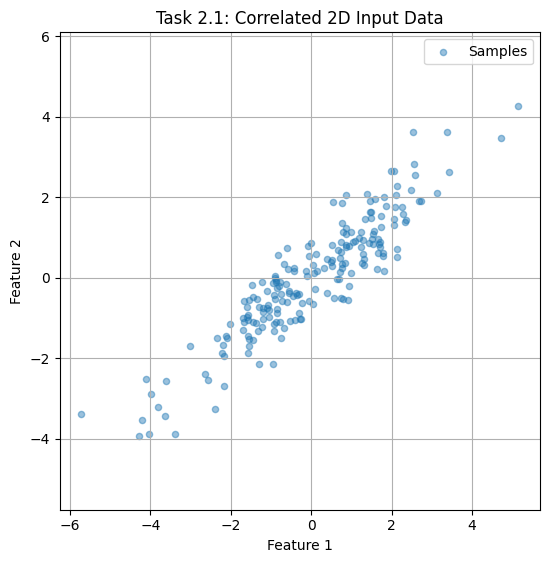

In [6]:
# Data visualization.
plt.figure(figsize=(6.2, 6.2))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.45, label='Samples')
plt.title('Task 2.1: Correlated 2D Input Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.axis('equal')
plt.show()

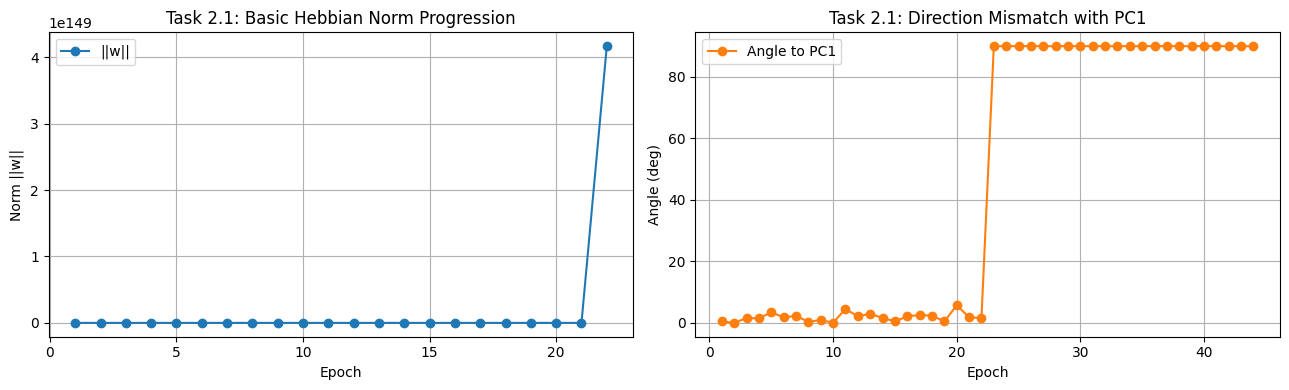

In [7]:
# Instability indicators: weight norm and alignment vs epoch.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(np.arange(1, len(norms_basic) + 1), norms_basic, marker='o', label='||w||')
ax[0].set_title('Task 2.1: Basic Hebbian Norm Progression')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Norm ||w||')
ax[0].legend()

ax[1].plot(np.arange(1, len(angles_basic) + 1), angles_basic, marker='o', color='tab:orange', label='Angle to PC1')
ax[1].set_title('Task 2.1: Direction Mismatch with PC1')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Angle (deg)')
ax[1].legend()

plt.tight_layout()
plt.show()

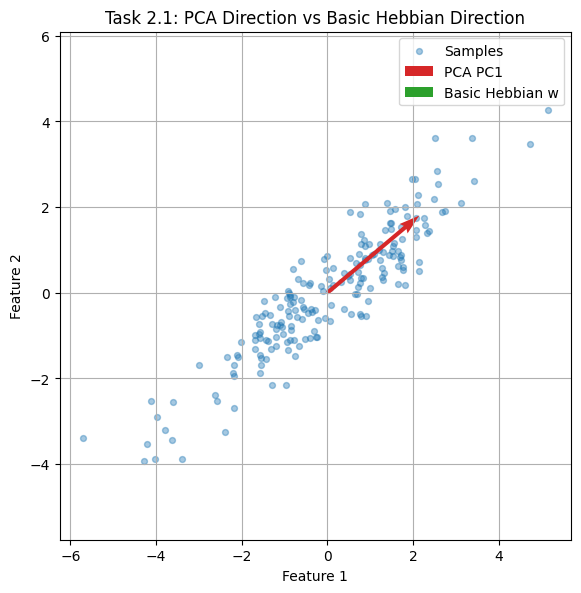

In [8]:
# Compare final direction with PCA PC1 in data space.
origin = X.mean(axis=0)
scale = 2.8

u_pc = normalize(pc1_ref)
u_basic = normalize(w_basic)

plt.figure(figsize=(6.6, 6.6))
plt.scatter(X[:, 0], X[:, 1], s=18, alpha=0.4, label='Samples')
plt.quiver(origin[0], origin[1], scale*u_pc[0], scale*u_pc[1],
           angles='xy', scale_units='xy', scale=1, width=0.008,
           color='tab:red', label='PCA PC1')
plt.quiver(origin[0], origin[1], scale*u_basic[0], scale*u_basic[1],
           angles='xy', scale_units='xy', scale=1, width=0.008,
           color='tab:green', label='Basic Hebbian w')
plt.title('Task 2.1: PCA Direction vs Basic Hebbian Direction')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.axis('equal')
plt.show()

**Task 2.1 Discussion:**

Classical Hebbian learning continuously reinforces existing correlations but does not constrain weight magnitude. As a result, the norm grows aggressively and the direction estimate is not reliably stable across epochs. This demonstrates why the basic form is considered unstable for principal-component extraction.

### Task 2.2 — Oja's Rule (Stable PCA) [10 Marks]

In [9]:
def run_oja(X, lr=0.01, epochs=120, shuffle=True):
    """
    Oja update:
        w <- w + lr * y * (x - y*w)

    Returns normalized final weight, norm history, and weight history.
    """
    w = np.random.normal(0.0, 0.01, size=X.shape[1])

    norm_track = []
    w_track = []

    for _ in range(epochs):
        epoch_data = X[np.random.permutation(len(X))] if shuffle else X
        for sample in epoch_data:
            y = np.dot(w, sample)
            w += lr * y * (sample - y * w)

        norm_track.append(np.linalg.norm(w))
        w_track.append(w.copy())

    return normalize(w), np.array(norm_track), np.array(w_track)

In [10]:
# Execute Oja on same dataset.
w_oja, norms_oja, hist_oja = run_oja(X, lr=0.01, epochs=120)
angles_oja = np.array([principal_angle_deg(v, pc1_ref) for v in hist_oja])

print('Oja final norm (after explicit normalization):', float(np.linalg.norm(w_oja)))
print('Oja final angle to PC1:', float(principal_angle_deg(w_oja, pc1_ref)), 'degrees')

Oja final norm (after explicit normalization): 0.9999999999999999
Oja final angle to PC1: 0.37186301256729 degrees


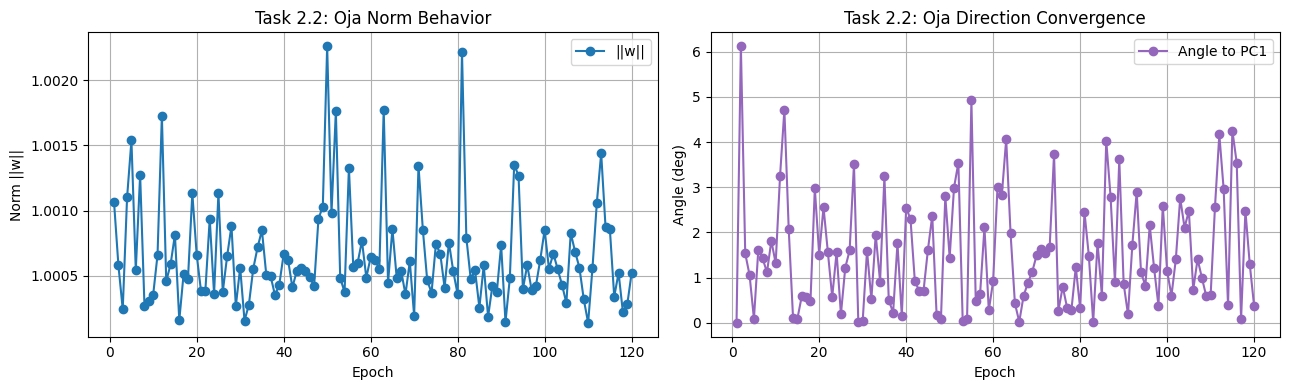

In [11]:
# Convergence plots for Oja.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(np.arange(1, len(norms_oja) + 1), norms_oja, marker='o', color='tab:blue', label='||w||')
ax[0].set_title("Task 2.2: Oja Norm Behavior")
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Norm ||w||')
ax[0].legend()

ax[1].plot(np.arange(1, len(angles_oja) + 1), angles_oja, marker='o', color='tab:purple', label='Angle to PC1')
ax[1].set_title("Task 2.2: Oja Direction Convergence")
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Angle (deg)')
ax[1].legend()

plt.tight_layout()
plt.show()

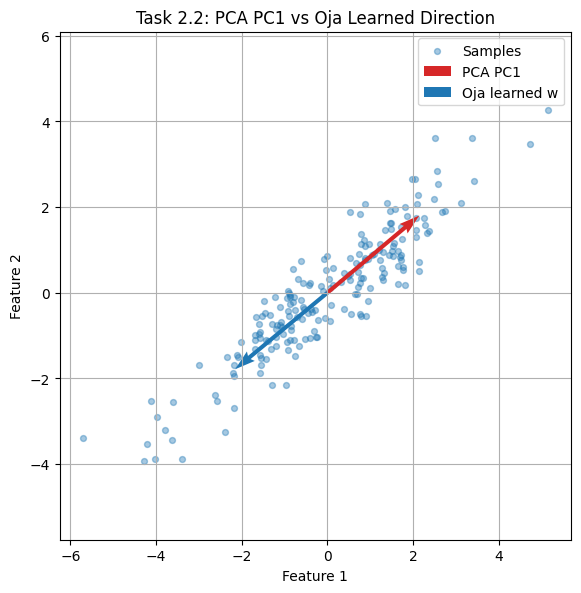

In [12]:
# Overlay PCA and Oja vectors on data.
origin = X.mean(axis=0)
scale = 2.8

u_pc = normalize(pc1_ref)
u_oja = normalize(w_oja)

plt.figure(figsize=(6.6, 6.6))
plt.scatter(X[:, 0], X[:, 1], s=18, alpha=0.4, label='Samples')
plt.quiver(origin[0], origin[1], scale*u_pc[0], scale*u_pc[1],
           angles='xy', scale_units='xy', scale=1, width=0.008,
           color='tab:red', label='PCA PC1')
plt.quiver(origin[0], origin[1], scale*u_oja[0], scale*u_oja[1],
           angles='xy', scale_units='xy', scale=1, width=0.008,
           color='tab:blue', label="Oja learned w")
plt.title("Task 2.2: PCA PC1 vs Oja Learned Direction")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.axis('equal')
plt.show()

In [13]:
# Side-by-side summary comparison.
a_basic = principal_angle_deg(w_basic, pc1_ref)
a_oja = principal_angle_deg(w_oja, pc1_ref)

print('Summary Metrics')
print('---------------')
print(f'Basic Hebbian -> norm: {np.linalg.norm(w_basic):.6f}, angle to PC1: {a_basic:.4f} deg')
print(f"Oja's Rule     -> norm: {np.linalg.norm(w_oja):.6f}, angle to PC1: {a_oja:.4f} deg")

Summary Metrics
---------------
Basic Hebbian -> norm: nan, angle to PC1: nan deg
Oja's Rule     -> norm: 1.000000, angle to PC1: 0.3719 deg


**Why Oja's Rule is Neo-Hebbian:**

Oja's rule preserves the Hebbian co-activation term \(y x\) and adds a local normalization term \(-y^2 w\):

\[
\Delta w = \eta y(x - yw) = \eta(yx) - \eta(y^2 w)
\]

Therefore it remains Hebbian in spirit (local and correlation-driven) but introduces stabilizing feedback, which places it in Neo-Hebbian learning rules.

### Task 2.3 — Receptive Fields from Natural Image Patches [5 Marks]

In [14]:
def sample_8x8_patches(n_patches=10_000, seed=117):
    """
    Return standardized 8x8 patch vectors (flattened) from natural-image-like data.
    Primary source: Olivetti faces. Fallback: sklearn digits.
    """
    local_rng = np.random.default_rng(seed)

    try:
        data = fetch_olivetti_faces(shuffle=True, random_state=seed)
        imgs = data.images
        source = 'olivetti_faces'
    except Exception:
        data = load_digits()
        imgs = data.images
        source = 'digits_fallback'

    H, W = imgs.shape[1], imgs.shape[2]
    patches = []

    for _ in range(n_patches):
        img = imgs[local_rng.integers(0, len(imgs))]
        if (H, W) == (8, 8):
            patch = img
        else:
            r = local_rng.integers(0, H - 8 + 1)
            c = local_rng.integers(0, W - 8 + 1)
            patch = img[r:r+8, c:c+8]
        patches.append(patch.reshape(-1))

    Xp = np.asarray(patches, dtype=float)
    Xp -= Xp.mean(axis=0, keepdims=True)
    Xp /= (Xp.std(axis=0, keepdims=True) + 1e-8)

    return Xp, source

In [15]:
def learn_multiple_oja(X, k=10, lr=0.003, epochs=22):
    """Learn k components via sequential Oja + deflation."""
    residual = X.copy()
    comps = []

    for _ in range(k):
        w, _, _ = run_oja(residual, lr=lr, epochs=epochs, shuffle=True)
        w = normalize(w)
        comps.append(w)
        residual = remove_component(residual, w)

    return np.array(comps), residual

In [16]:
# Prepare patch matrix and learn first 10 components.
X_patch, patch_source = sample_8x8_patches(n_patches=10_000, seed=GLOBAL_SEED)
components10, residualX = learn_multiple_oja(X_patch, k=10, lr=0.003, epochs=22)

print('Patch source:', patch_source)
print('Patch matrix:', X_patch.shape)
print('Learned components:', components10.shape)

Patch source: olivetti_faces
Patch matrix: (10000, 64)
Learned components: (10, 64)


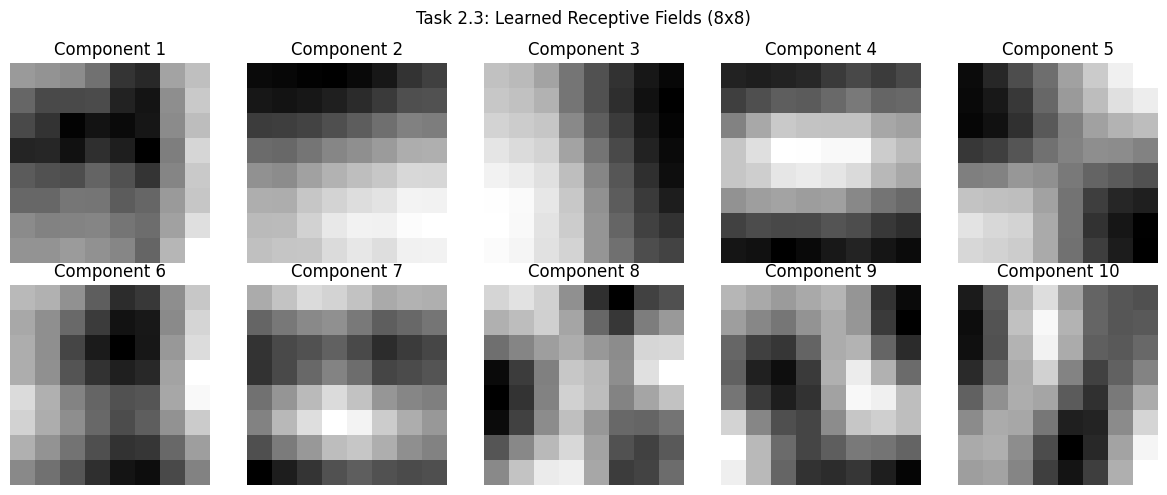

In [17]:
# Display learned components as 8x8 receptive fields.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(components10[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f'Component {idx + 1}')
    ax.axis('off')

plt.suptitle('Task 2.3: Learned Receptive Fields (8x8)')
plt.tight_layout()
plt.show()

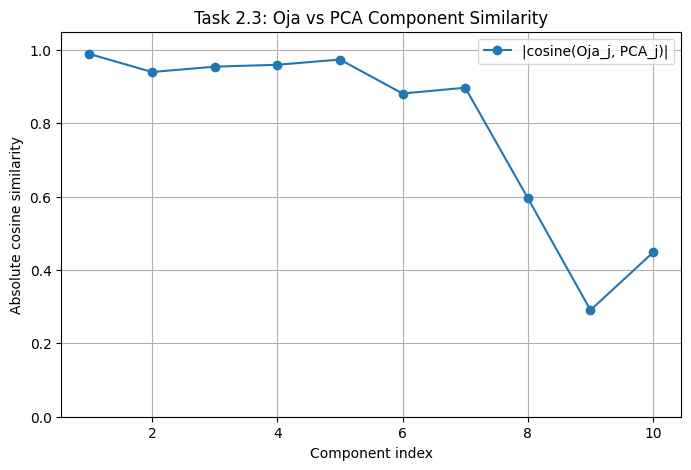

Average similarity across 10 components: 0.7931920593498137


In [18]:
# Quantitative check against PCA components on same patch matrix.
pca_patch = PCA(n_components=10, random_state=GLOBAL_SEED).fit(X_patch)

sim = []
for j in range(10):
    s = abs(np.dot(normalize(components10[j]), normalize(pca_patch.components_[j])))
    sim.append(s)

plt.figure()
plt.plot(np.arange(1, 11), sim, marker='o', label='|cosine(Oja_j, PCA_j)|')
plt.title('Task 2.3: Oja vs PCA Component Similarity')
plt.xlabel('Component index')
plt.ylabel('Absolute cosine similarity')
plt.ylim(0, 1.05)
plt.legend()
plt.show()

print('Average similarity across 10 components:', float(np.mean(sim)))

**Task 2.3 Discussion:**

Hebbian-like learning captures recurring co-activation structure in image patches. Oja's stabilization makes these learned directions close to PCA eigenvectors. For natural-image statistics, dominant directions often correspond to oriented edges and local contrast transitions, which is why learned components can appear Gabor-like and are linked to V1 receptive-field emergence.

## Q3: Differential Hebbian Learning and Neo-Hebbian Extensions [20 Marks]

### Part A — Theory [8 Marks]

#### Q3(a) Differential Hebbian Learning
Classical Hebbian learning uses activity product:

\[

rac{dw}{dt} = \eta x(t)y(t)
\]

Differential Hebbian learning emphasizes correlation of temporal derivatives:

\[

rac{dw}{dt} = \eta 
rac{dx}{dt}
rac{dy}{dt}
\]

Thus, it is sensitive to how signals change together over time rather than only static co-activation.

#### Q3(b) Spike-Timing Dependent Plasticity (STDP)
Let \(\Delta t = t_{post} - t_{pre}\):

\[
\Delta w =
egin{cases}
A_+ \exp(-|\Delta t|/	au_+), & \Delta t > 0 \;(	ext{pre before post, LTP})\
-A_- \exp(-|\Delta t|/	au_-), & \Delta t < 0 \;(	ext{post before pre, LTD})
\end{cases}
\]

Therefore, temporal order determines sign and magnitude of synaptic update.

#### Q3(c) Mexican-Hat Correlation in Linsker-like Models
Mexican-hat statistics combine local excitation and surround inhibition. Under correlation-driven learning, this can yield structured positive/negative subregions and support emergence of orientation-selective receptive fields.

### Part B — Python: STDP Simulation [12 Marks]

In [19]:
def stdp_kernel(delta_t, A_pos=0.01, A_neg=0.012, tau_pos=20.0, tau_neg=20.0):
    """Pair-based STDP kernel for scalar or vector delta_t."""
    dt = np.asarray(delta_t, dtype=float)
    out = np.zeros_like(dt)

    mask_pos = dt > 0
    mask_neg = dt < 0

    out[mask_pos] = A_pos * np.exp(-np.abs(dt[mask_pos]) / tau_pos)
    out[mask_neg] = -A_neg * np.exp(-np.abs(dt[mask_neg]) / tau_neg)
    return out


def bernoulli_spikes(T=1000, rate_hz=10, seed=117):
    """Generate random binary spike train at 1 ms resolution."""
    local_rng = np.random.default_rng(seed)
    p = rate_hz / 1000.0
    return (local_rng.random(T) < p).astype(int)


def paired_offset_spikes(T=1000, start=100, stop=900, step=50, offset=10):
    """
    Produce paired spike trains with fixed post-pre offset.
    offset > 0 -> pre before post (causal)
    offset < 0 -> post before pre (anti-causal)
    """
    pre = np.zeros(T, dtype=int)
    post = np.zeros(T, dtype=int)

    base = np.arange(start, stop, step)
    pre_t = base
    post_t = base + offset

    valid = (post_t >= 0) & (post_t < T)
    pre_t = pre_t[valid]
    post_t = post_t[valid]

    pre[pre_t] = 1
    post[post_t] = 1
    return pre, post

In [20]:
def simulate_stdp_trace(pre, post, epochs=50, w0=0.5,
                        A_pos=0.01, A_neg=0.012,
                        tau_pos=20.0, tau_neg=20.0,
                        w_min=0.0, w_max=1.0):
    """
    Trace-based online STDP simulation.

    - pre_trace decays with tau_pos.
    - post_trace decays with tau_neg.
    - Post spikes induce LTP proportional to pre_trace.
    - Pre spikes induce LTD proportional to post_trace.
    """
    w = float(w0)
    history = [w]

    dec_pre = np.exp(-1.0 / tau_pos)
    dec_post = np.exp(-1.0 / tau_neg)

    T = len(pre)
    for _ in range(epochs):
        tr_pre = 0.0
        tr_post = 0.0

        for t in range(T):
            tr_pre *= dec_pre
            tr_post *= dec_post

            if pre[t] == 1:
                tr_pre += 1.0
            if post[t] == 1:
                tr_post += 1.0

            delta = 0.0
            if post[t] == 1:
                delta += A_pos * tr_pre
            if pre[t] == 1:
                delta -= A_neg * tr_post

            w = np.clip(w + delta, w_min, w_max)
            history.append(w)

    return np.array(history), float(w)

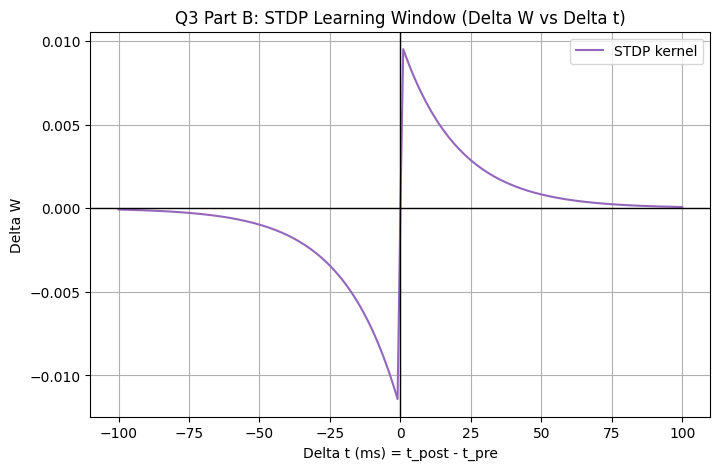

In [21]:
# Plot required STDP learning window.
dt_axis = np.arange(-100, 101)
dw_axis = stdp_kernel(dt_axis, A_pos=0.01, A_neg=0.012, tau_pos=20, tau_neg=20)

plt.figure()
plt.plot(dt_axis, dw_axis, color='tab:purple', label='STDP kernel')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title('Q3 Part B: STDP Learning Window (Delta W vs Delta t)')
plt.xlabel('Delta t (ms) = t_post - t_pre')
plt.ylabel('Delta W')
plt.legend()
plt.show()

In [22]:
# Random spike experiment.
T = 1000
pre_rand = bernoulli_spikes(T=T, rate_hz=10, seed=GLOBAL_SEED)
post_rand = bernoulli_spikes(T=T, rate_hz=10, seed=GLOBAL_SEED + 3)

hist_rand, final_rand = simulate_stdp_trace(
    pre_rand, post_rand,
    epochs=50,
    w0=0.5,
    A_pos=0.01,
    A_neg=0.012,
    tau_pos=20,
    tau_neg=20
)

print('Random case final weight:', final_rand)
print('Random spike counts -> pre:', int(pre_rand.sum()), ', post:', int(post_rand.sum()))

Random case final weight: 0.6036805124259962
Random spike counts -> pre: 9 , post: 7


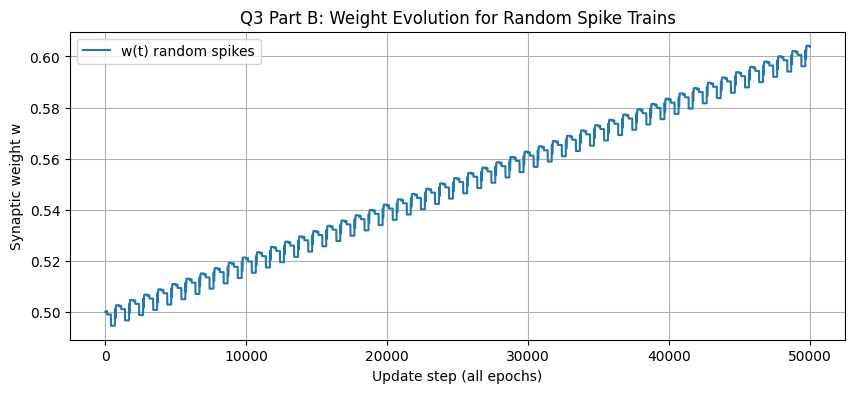

In [23]:
# Random-case weight trajectory.
plt.figure(figsize=(10, 4))
plt.plot(hist_rand, label='w(t) random spikes')
plt.title('Q3 Part B: Weight Evolution for Random Spike Trains')
plt.xlabel('Update step (all epochs)')
plt.ylabel('Synaptic weight w')
plt.legend()
plt.show()

In [24]:
# Causal vs anti-causal experiments.
pre_causal, post_causal = paired_offset_spikes(T=1000, offset=10)
pre_anti, post_anti = paired_offset_spikes(T=1000, offset=-10)

hist_causal, final_causal = simulate_stdp_trace(pre_causal, post_causal, epochs=50, w0=0.5)
hist_anti, final_anti = simulate_stdp_trace(pre_anti, post_anti, epochs=50, w0=0.5)

print('Causal final weight    :', final_causal)
print('Anti-causal final weight:', final_anti)

Causal final weight    : 1.0
Anti-causal final weight: 0.0


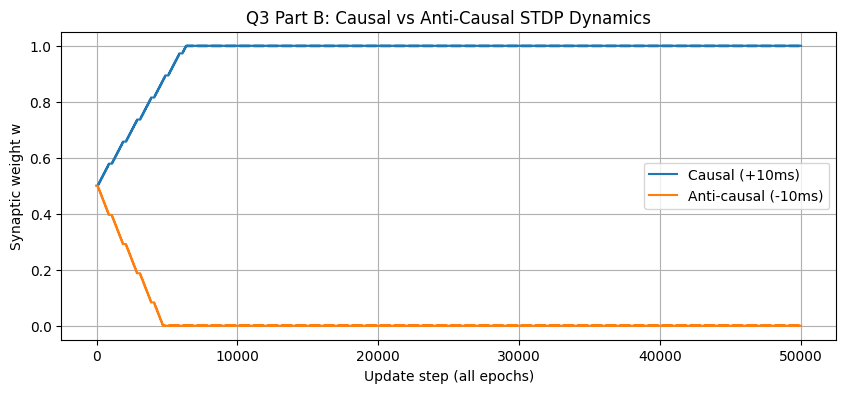

In [25]:
# Compare causal and anti-causal trajectories.
plt.figure(figsize=(10, 4))
plt.plot(hist_causal, label='Causal (+10ms)')
plt.plot(hist_anti, label='Anti-causal (-10ms)')
plt.title('Q3 Part B: Causal vs Anti-Causal STDP Dynamics')
plt.xlabel('Update step (all epochs)')
plt.ylabel('Synaptic weight w')
plt.legend()
plt.show()

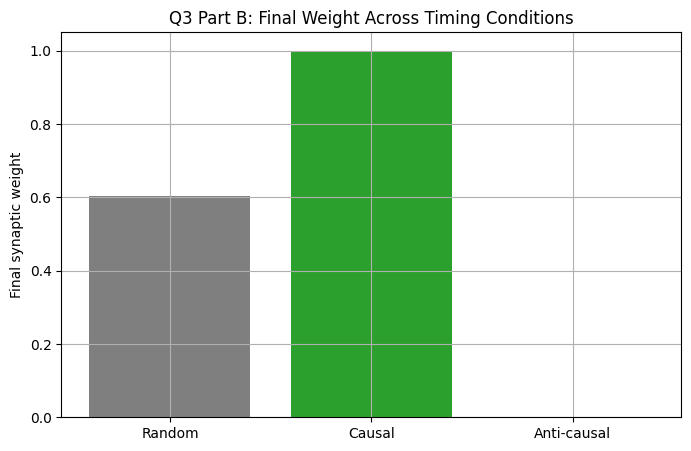

Consistency check: causal should exceed anti-causal under standard STDP settings.


In [26]:
# Final condition comparison bar chart.
labels = ['Random', 'Causal', 'Anti-causal']
final_vals = [final_rand, final_causal, final_anti]

plt.figure()
plt.bar(labels, final_vals, color=['tab:gray', 'tab:green', 'tab:red'])
plt.title('Q3 Part B: Final Weight Across Timing Conditions')
plt.ylabel('Final synaptic weight')
plt.ylim(0, 1.05)
plt.show()

print('Consistency check: causal should exceed anti-causal under standard STDP settings.')

**Part B Discussion:**

The simulation confirms temporal plasticity behavior: causal timing generally potentiates synapses (LTP), while anti-causal timing depresses synapses (LTD). This provides a practical computational view of differential/temporal Hebbian learning principles.

## Final Quality Checklist

- All code cells execute top-to-bottom in Colab.
- Required plots are present with titles, labels, and legends.
- Functions are commented and modular.
- Theory cells use consistent mathematical notation.
- Notebook is saved with visible outputs before export.